# Анализ датасета полупроводниковых измерений

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import shap
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, IsolationForest
# from xgboost import XGBClassifier
from sklearn.metrics import f1_score, matthews_corrcoef, roc_auc_score, average_precision_score, confusion_matrix, classification_report
from sklearn.pipeline import make_pipeline
# from sklearn.inspection import permutation_importance
# from sklearn.svm import OneClassSVM
# from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.decomposition import PCA
from scipy.stats import chi2
from spc_lib.charts import IMRChart


warnings.filterwarnings('ignore')

## 1. Предобработка

In [2]:
df = pd.read_csv('semiconductor_data.csv')
df.head()

,Unnamed: 0,Sensor_01,Sensor_02,Sensor_03,Sensor_04,Sensor_05,Sensor_06,Sensor_07,Sensor_08,Sensor_09,...,Sensor_61,Sensor_62,Sensor_63,Sensor_64,Sensor_65,Sensor_66,Sensor_67,Sensor_68,Pass/Fail,Time
0,0,85.806100,171.004721,138.971849,118.240786,NaN,3.897557,2546.982328,57.818861,15.038362,...,NaN,40.753390,NaN,125.421235,133.264953,112.141233,149.164463,117.954849,0,2024-01-01 00:00:00
1,1,86.046002,172.817682,140.027364,119.895054,52.647217,4.029836,2650.674032,58.959799,15.915649,...,75.059031,40.872408,64.174857,126.034825,134.554354,112.321838,150.104725,118.536785,0,2024-01-01 01:00:00
2,2,85.772996,172.006285,139.141684,119.245716,52.415836,3.941542,2699.998891,59.672548,15.510368,...,74.912435,41.902232,65.315622,124.726663,135.274275,113.390410,150.406438,NaN,0,2024-01-01 02:00:00
3,3,85.747684,171.345199,139.723506,119.358777,52.598005,3.971674,2680.813430,59.497590,15.287677,...,75.643528,43.120728,66.080566,127.344902,135.237106,113.237793,NaN,119.723361,0,2024-01-01 03:00:00
4,4,NaN,173.163053,140.756343,120.732388,55.225609,4.194291,2791.151097,62.581936,15.809746,...,75.514722,40.831293,63.085823,125.229185,134.126170,111.834879,151.044639,118.716300,0,2024-01-01 04:00:00


In [3]:
df.shape

(2000, 71)

In [4]:
del df['Unnamed: 0']

In [5]:
df.isna().sum().sum()

np.int64(6854)

<Axes: >

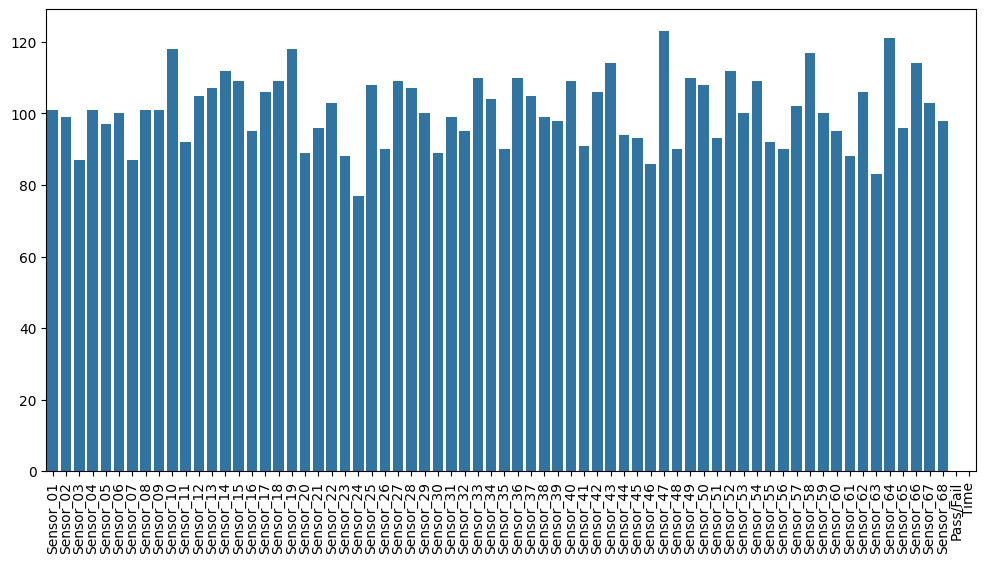

In [6]:
plt.figure(figsize=(12, 6))

plt.xticks(rotation=90)
sns.barplot(df.isna().sum(), )

Nan разбросаны по фичам ~ равномерно 

Text(0.5, 1.0, 'Соотношение Pass/Fail')

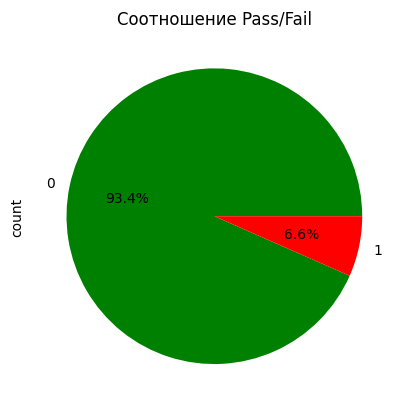

In [7]:
df['Pass/Fail'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['green', 'red'])
plt.title('Соотношение Pass/Fail')

In [8]:
X = df.drop(columns=['Time', 'Pass/Fail'])
y = df['Pass/Fail']

In [9]:
constant_cols = [col for col in X.columns if X[col].nunique() <= 1]
len(constant_cols)

0

Train / test split 

In [10]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=57, stratify=y)

KNNImputer + StandardScaler 

In [11]:
# imputer = KNNImputer(n_neighbors=5)
# X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train_raw), columns=X.columns, index=X_train_raw.index)
# X_test_imputed = pd.DataFrame(imputer.transform(X_test_raw), columns=X.columns, index=X_test_raw.index)

# scaler = StandardScaler()
# X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imputed), columns=X.columns, index=X_train_imputed.index)
# X_test_scaled = pd.DataFrame(scaler.transform(X_test_imputed), columns=X.columns, index=X_test_imputed.index)

Посмотрим, есть ли высоко коррелированные фичи

In [12]:
corr_matrix = np.corrcoef(X_train_raw.to_numpy().T)

high_corr = np.where(np.abs(corr_matrix) > 0.95)

np.sum(high_corr[0] - high_corr[1])

np.int64(0)

## 2. Обучение моделей: Random Forest 

In [37]:
import optuna

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 400),
        'max_depth': trial.suggest_int('max_depth', 2, 64, log=True),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
    }

    n_neighbors=trial.suggest_int('imputer__n_neighbors', 2, 10)

    pipeline = make_pipeline(KNNImputer(n_neighbors=n_neighbors), StandardScaler(), RandomForestClassifier(**params, random_state=57, n_jobs=-1))

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=57)
    scores = cross_val_score(
        pipeline,
        X_train_raw,
        y_train,
        cv=cv,
        scoring='matthews_corrcoef'
    )

    return np.mean(scores)

study = optuna.create_study(direction='maximize')

study.optimize(objective, n_trials=70)

[I 2026-07-07 23:10:45,948] A new study created in memory with name: no-name-6a34078b-ae2c-40d3-8e96-df0924f93ec8


[I 2026-07-07 23:10:49,905] Trial 0 finished with value: 0.0 and parameters: {'n_estimators': 162, 'max_depth': 54, 'min_samples_split': 8, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'imputer__n_neighbors': 4}. Best is trial 0 with value: 0.0.
[I 2026-07-07 23:10:54,806] Trial 1 finished with value: 0.0 and parameters: {'n_estimators': 243, 'max_depth': 3, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'imputer__n_neighbors': 5}. Best is trial 0 with value: 0.0.
[I 2026-07-07 23:10:59,213] Trial 2 finished with value: 0.0 and parameters: {'n_estimators': 203, 'max_depth': 4, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'imputer__n_neighbors': 8}. Best is trial 0 with value: 0.0.
[I 2026-07-07 23:11:01,766] Trial 3 finished with value: 0.0 and parameters: {'n_estimators': 60, 'max_depth': 16, 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_features': 'log2', 'imputer__n_neighbors': 8}. Best is trial 0 with value: 0.0.
[I 2026-07

In [38]:
print(f"Лучшие гиперпараметры: {study.best_params}")
print(f"Лучшая mcc: {study.best_value:.4f}")

Лучшие гиперпараметры: {'n_estimators': 256, 'max_depth': 16, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': None, 'imputer__n_neighbors': 3}
Лучшая mcc: 0.5829


Тюним порог

In [39]:
best_params = study.best_params

n_neighbors = best_params.pop('imputer__n_neighbors')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=57)

oof_proba = np.zeros(len(X_train_raw))
oof_labels = y_train.values.copy()

for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_train_raw, y_train)):

    X_fold_train = X_train_raw.iloc[train_idx]
    X_fold_val = X_train_raw.iloc[val_idx]
    y_fold_train = y_train.iloc[train_idx]

    final_pipeline = make_pipeline(KNNImputer(n_neighbors=n_neighbors), StandardScaler(), RandomForestClassifier(**best_params, random_state=57, n_jobs=-1))

    final_pipeline.fit(X_fold_train, y_fold_train)

    oof_proba[val_idx] = final_pipeline.predict_proba(X_fold_val)[:, 1]

thresholds = np.linspace(0.1, 0.9, 50)
best_threshold = 0.5
best_mcc = -1
best_f1 = -1

mcc_list = []

for thresh in thresholds:
    y_pred_oof = (oof_proba >= thresh).astype(int)
    mcc = matthews_corrcoef(y_train, y_pred_oof)
    f1 = f1_score(y_train, y_pred_oof)
    mcc_list.append(mcc)
    if mcc > best_mcc:
        best_mcc = mcc
        best_f1 = f1
        best_threshold = thresh

best_threshold, max(mcc_list)

(np.float64(0.42653061224489797), 0.6124361211196071)

<BarContainer object of 50 artists>

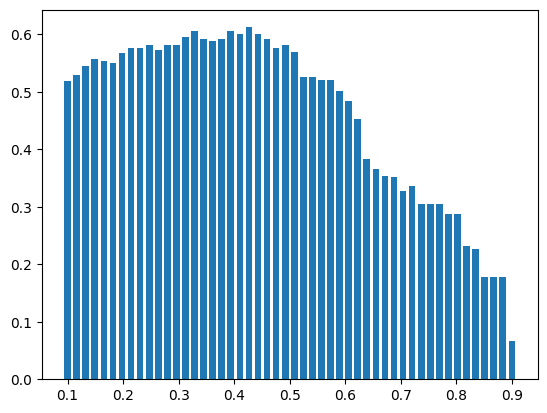

In [40]:
plt.bar(thresholds, mcc_list, width=0.012)

Проверим на тесте

In [41]:
final_pipeline.fit(X_train_raw, y_train)

y_pred_proba = final_pipeline.predict_proba(X_test_raw)[:, 1]
y_pred = (y_pred_proba >= best_threshold).astype(int)

test_mcc = matthews_corrcoef(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_pred_proba)
test_pr_auc = average_precision_score(y_test, y_pred_proba)

print(f"MCC: {test_mcc:.4f}")
print(f"F1-score: {test_f1:.4f}")
print(f"ROC-AUC: {test_auc:.4f}")
print(f"PR-AUC: {test_pr_auc:.4f}")

MCC: 0.5544
F1-score: 0.5672
ROC-AUC: 0.8694
PR-AUC: 0.5266


## SHAP Анализ

In [21]:
explainer = shap.TreeExplainer(final_pipeline.named_steps['randomforestclassifier'])
shap_values = explainer.shap_values(X_test_raw)
shap_values.shape

(600, 68, 2)

In [22]:
shap_importance = np.abs(shap_values).mean(axis=0)

df_importance = pd.DataFrame({
    'sensors': X_test_raw.columns,
    'importance': shap_importance[:, 1]
}).sort_values(by='importance', ascending=False)

df_importance

,sensors,importance
28,Sensor_29,0.120511
19,Sensor_20,0.105330
4,Sensor_05,0.067326
50,Sensor_51,0.065033
58,Sensor_59,0.053351
...,...,...
61,Sensor_62,0.000428
29,Sensor_30,0.000421
43,Sensor_44,0.000408
65,Sensor_66,0.000358


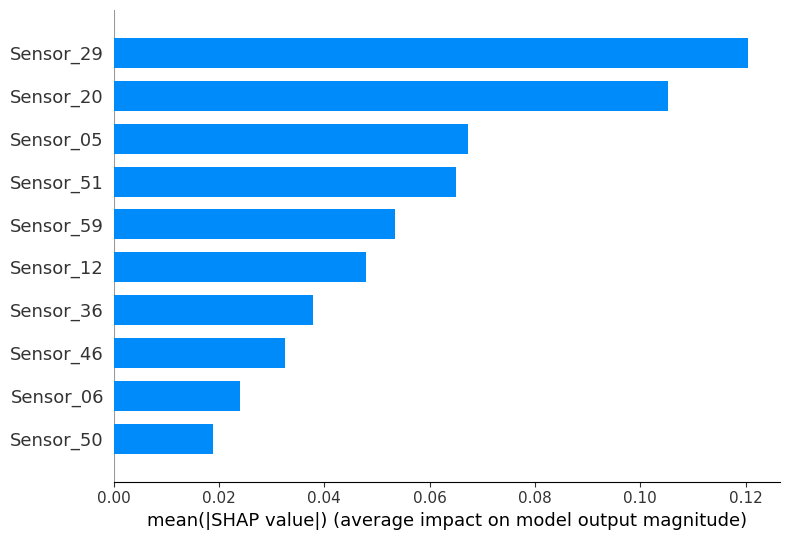

In [23]:
shap.summary_plot(shap_importance.T, X_test_raw, plot_type="bar", max_display=10, show=True)

## Boxplot Top-5 датчиков

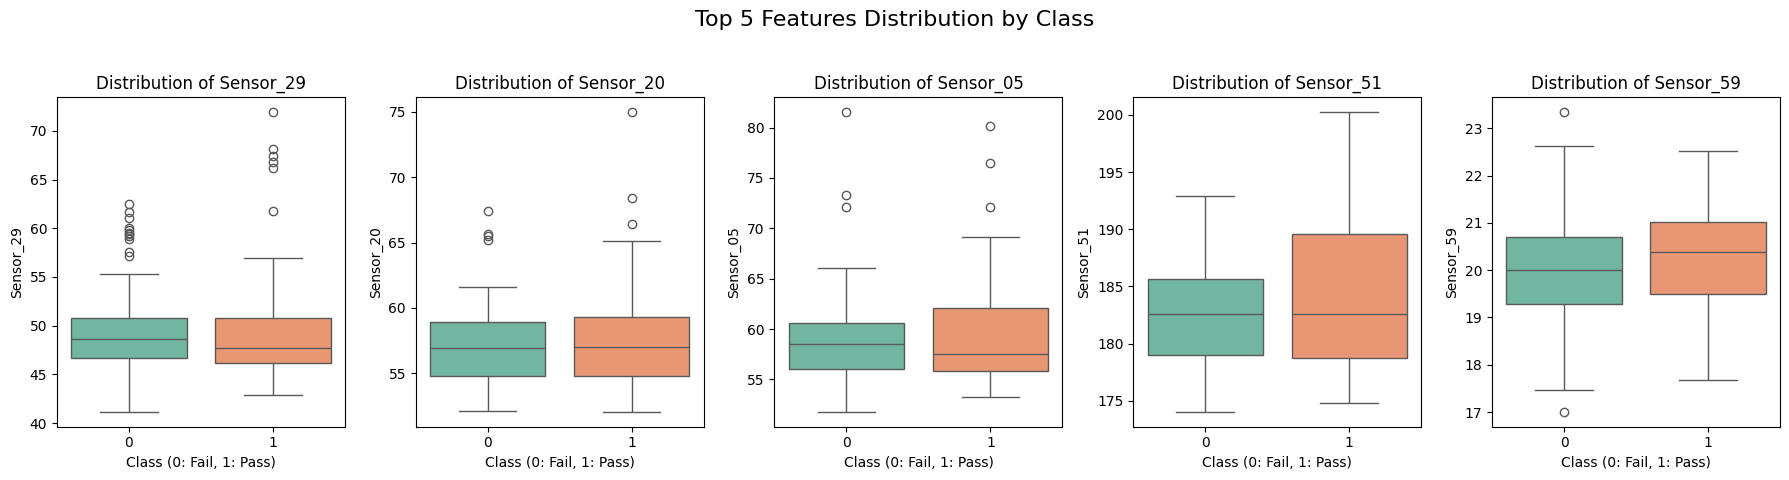

In [24]:
top_5_sensors = df_importance.head(5)['sensors'].tolist()
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for i, sensor in enumerate(top_5_sensors):
    sns.boxplot(x=y_test, y=X_test_raw[sensor], ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribution of {sensor}', fontsize=12)
    axes[i].set_xlabel('Class (0: Fail, 1: Pass)')

plt.suptitle('Top 5 Features Distribution by Class', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Мало что интересного можно сказать по данным боксплотам

## ACF + PACF

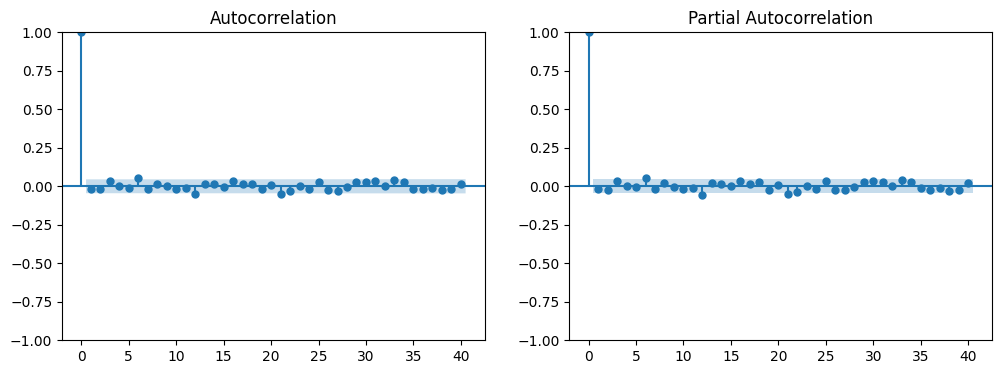

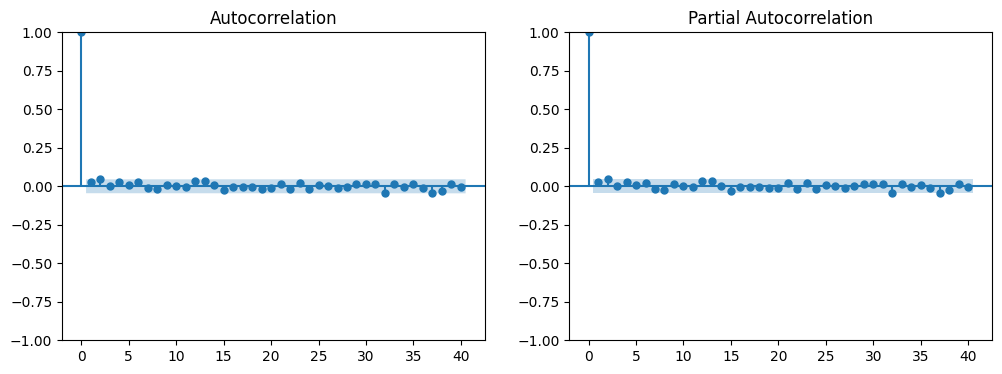

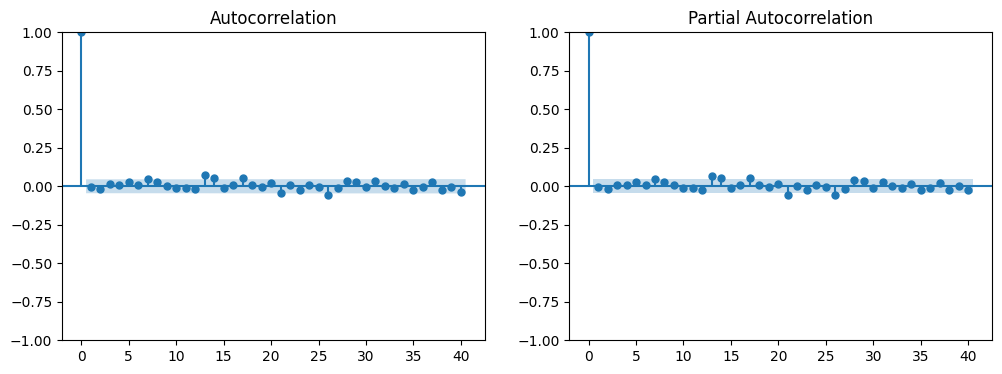

In [ ]:
for i in range(3):
    sensor = top_5_sensors[i]
    data = X[sensor].dropna()  # Убираем NaN

    # Графики
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    plot_acf(data, ax=ax1, lags=40)
    plot_pacf(data, ax=ax2, lags=40)
    plt.show()

Анализ на автокорреляцию проводился с целью понять в какую сторону двигаться. Если бы данные были автокоррелированы, то имело бы смысл двигаться в сторону временных рядов. В нашем случае выполнено необходимое предположение для построения контрольных карт.

## I-Mr charts + анализ дрейфа
spc_lib: https://github.com/denccchick/spc_lib

In [36]:
for sensor in top_5_sensors:
    # Заполняем NaN через KNNImputer
    sensor_data_with_nan = X_test_raw[[sensor]]
    imputer = KNNImputer(n_neighbors=5)
    sensor_data_clean = imputer.fit_transform(sensor_data_with_nan)

    chart = IMRChart(data=sensor_data_clean, datetimes=np.arange(len(sensor_data_clean)))

    chart.fit()

    fig_i, fig_mr = chart.plot()
    fig_i.show()
    fig_mr.show()

    fig_rules = chart.plot_rules(n_cols=1)
    fig_rules.show()


Имеет смысл проанализировать взаимосвязь срабатывания критериев и формирования брака

## MSPC (Multivariate Statistical Process Control)

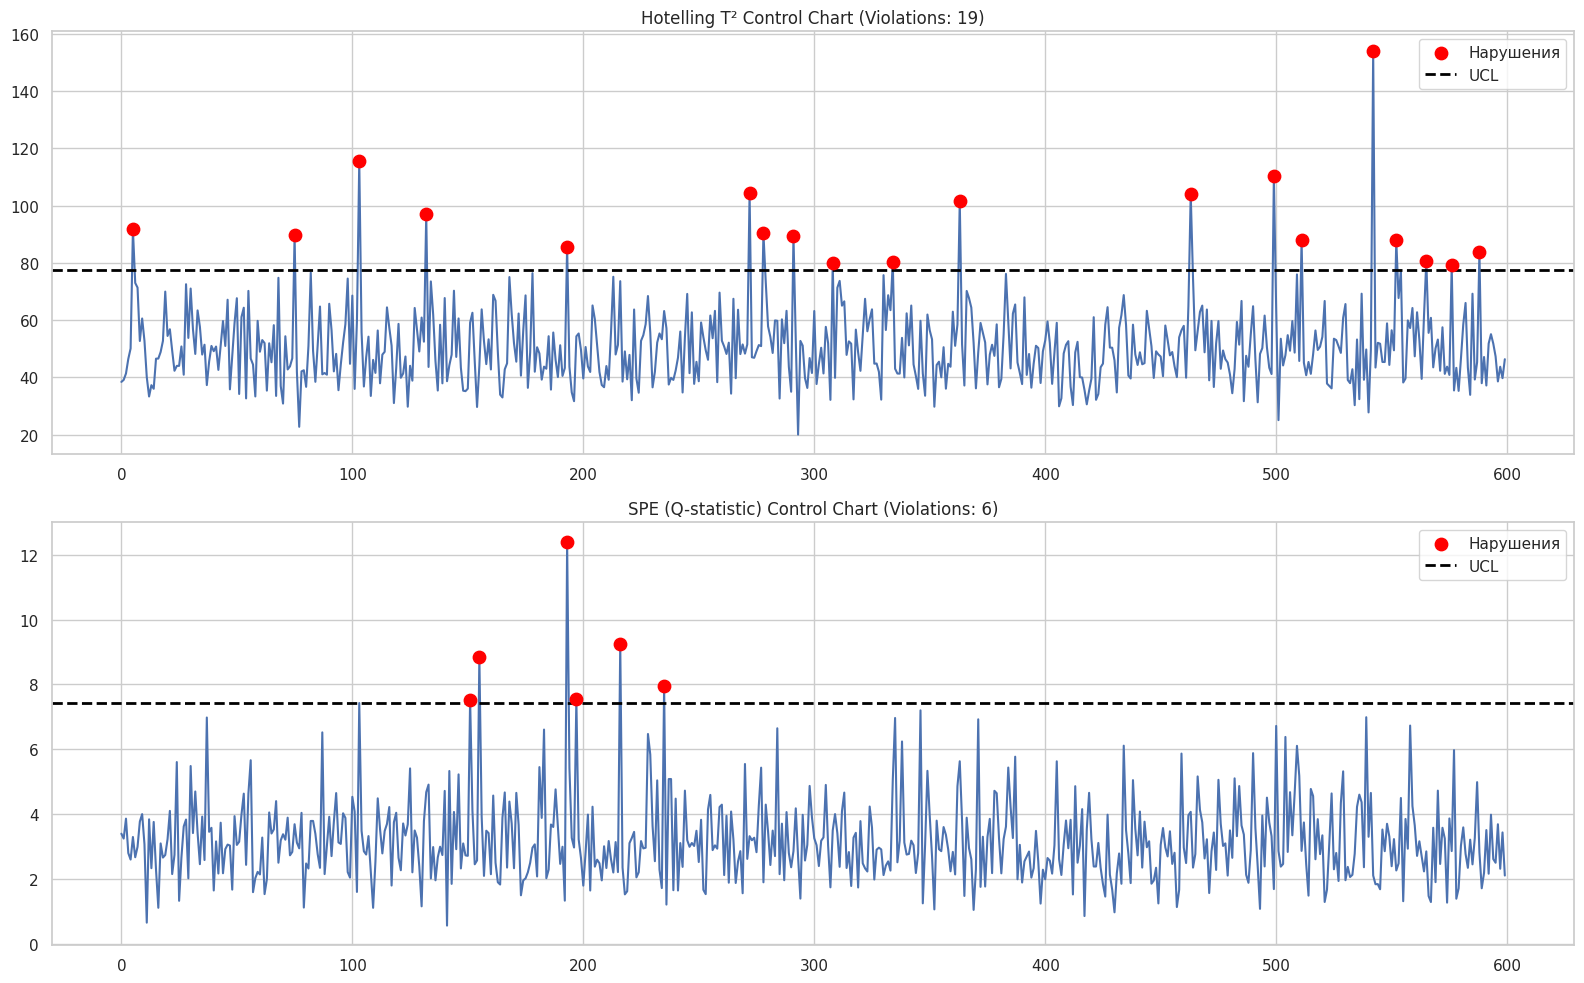

In [ ]:
# Используем X_test_scaled
pca_mspc = PCA(n_components=0.95)
scores = pca_mspc.fit_transform(X_test_raw)
reconstructed = pca_mspc.inverse_transform(scores)

# Hotelling T²
cov_scores = np.cov(scores.T)
cov_inv = np.linalg.pinv(cov_scores)
t2_values = np.array([s.T @ cov_inv @ s for s in scores])
ucl_t2 = chi2.ppf(0.99, df=scores.shape[1])

# SPE (Q-statistic)
residuals = X_test_raw.values - reconstructed
spe_values = np.sum(residuals**2, axis=1)
ucl_spe = np.percentile(spe_values, 99)

# Нарушения
t2_outliers = np.where(t2_values > ucl_t2)[0]
spe_outliers = np.where(spe_values > ucl_spe)[0]
total_mspc_anomalies = len(np.union1d(t2_outliers, spe_outliers))

# Визуализация
fig, axes = plt.subplots(2, 1, figsize=(16,10))

# Hotelling T² Plot
axes[0].plot(t2_values, lw=1.5)
axes[0].scatter(t2_outliers, t2_values[t2_outliers], s=80, marker='o', zorder=5, label='Нарушения', color='red')
axes[0].axhline(ucl_t2, linestyle='--', linewidth=2, label='UCL', color='black')
axes[0].set_title(f'Hotelling T² Control Chart (Violations: {len(t2_outliers)})')
axes[0].legend()

# SPE Plot
axes[1].plot(spe_values, lw=1.5)
axes[1].scatter(spe_outliers, spe_values[spe_outliers], s=80, marker='o', zorder=5, label='Нарушения', color='red')
axes[1].axhline(ucl_spe, linestyle='--', linewidth=2, label='UCL', color='black')
axes[1].set_title(f'SPE (Q-statistic) Control Chart (Violations: {len(spe_outliers)})')
axes[1].legend()

plt.tight_layout()
plt.show()